In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")

In [13]:
# Contar cuántas muestras hay por cada clase (0, 1, 2)
valores, conteos = np.unique(target, return_counts=True)

for val, count in zip(valores, conteos):
    print(f"Clase {val}: {count} muestras")

Clase 0: 50 muestras
Clase 1: 50 muestras
Clase 2: 50 muestras


In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 50
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 100
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]
[7.  3.2 4.7 1.4]
1
[0 1 0]
[6.3 3.3 6.  2.5]
2
[0 0 1]


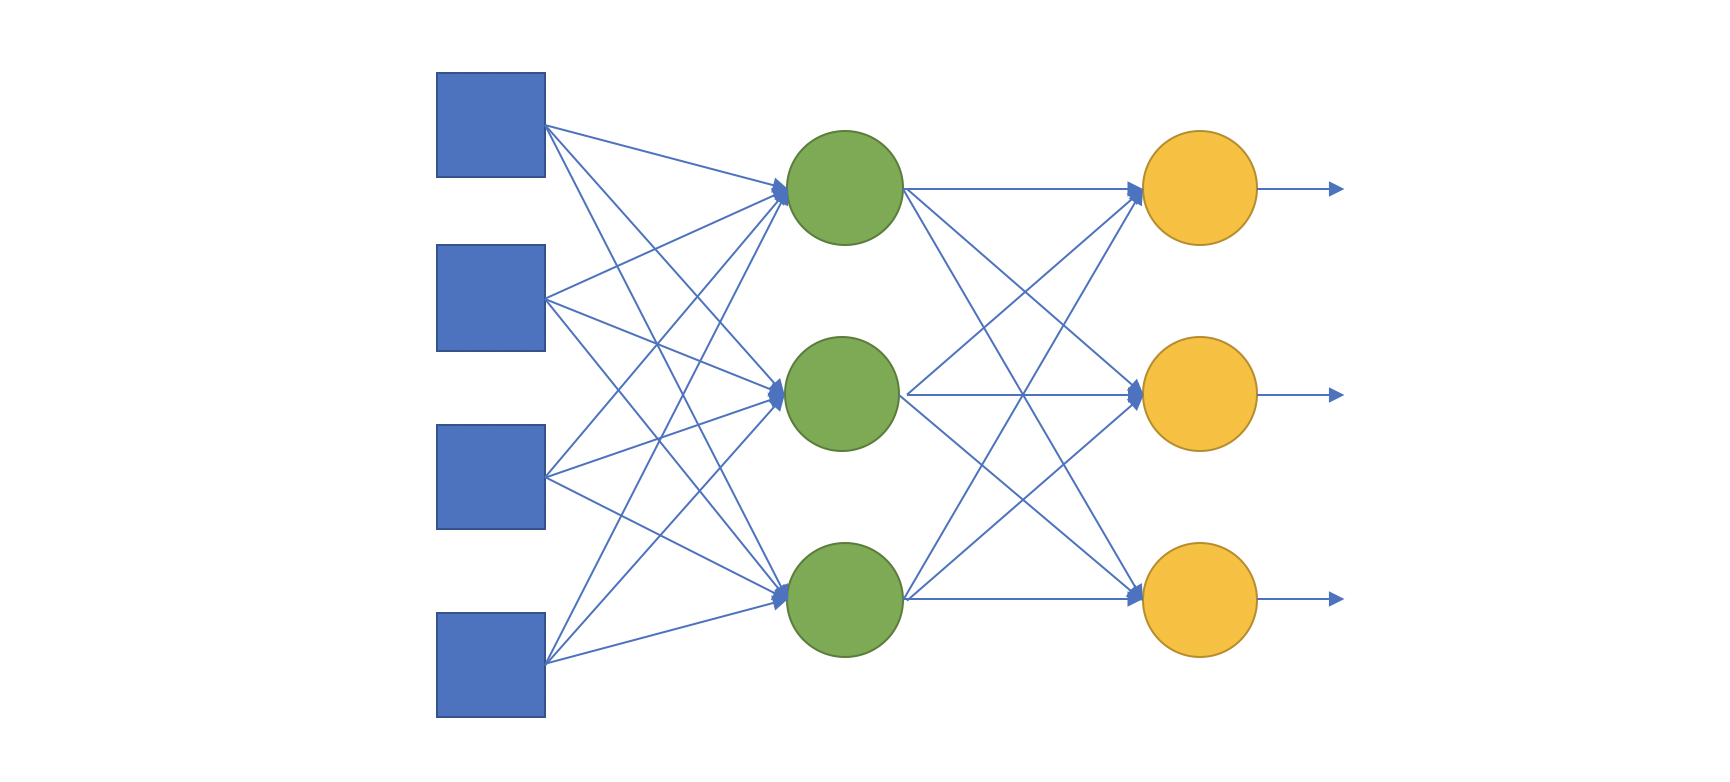

In [4]:
#Topology: 4 x 3 x 3
input_size_layer1 = 4
num_neurons_layer1 = 3

input_size_layer2 = num_neurons_layer1
num_neurons_layer2 = 3

layer1 = list()
layer2 = list()

In [5]:
def generate_weights(num_weights):
  w = np.zeros(num_weights)
  for i in range(len(w)):
    w[i] = (np.random.rand(1) - 0.5)
  return w

def init_weights():
  layer1.clear()
  layer2.clear()
  for i in range(num_neurons_layer1):
    layer1.append( generate_weights(input_size_layer1+1)) # plus 1 -> plus bias
  for i in range(num_neurons_layer2):
    layer2.append( generate_weights(input_size_layer2+1)) # plus 1 -> plus bias

def net_input(input_vector, w):
  net_input_var = w[0]
  for i in range(len(input_vector)):
    net_input_var += w[i+1] * input_vector[i]
  return net_input_var

def sigmoid(z):
  activation = 1/(1+np.power(np.e, -z))
  return activation

def propagate(X, w):
  neuronInput = net_input(X, w) # Sigma
  neuronOutput = sigmoid(neuronInput) # sigma
  return neuronOutput

def calculate_error():
  total_err = 0
  for idx in range(len(X)):
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[idx], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

    err = Y[idx] - output_layer2
    err = np.power(err,2)
    err = err.sum()
    total_err += err

  return total_err / ( len(X) )

In [6]:
print(generate_weights(5))

[ 0.36465645 -0.23993006  0.04756667  0.13340466  0.37937786]


/tmp/ipykernel_580/1036443924.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w[i] = (np.random.rand(1) - 0.5)


In [7]:
alpha = 0.03
epochs = 500

init_weights()

E = list()
E.append( calculate_error() )
for e in range(epochs):
  for d in range(len(X)):
    # Etapa 1 - Propagación
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[d], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

    # Etapa 2 - Retropropagación de los errores
    delta_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(delta_layer2)):
      delta_layer2[i] = output_layer2[i] * (1 - output_layer2[i]) * (Y[d][i] - output_layer2[i])

    for i in range(len(layer2)):
      layer2[i][0] += alpha * delta_layer2[i] * 1
      for j in range(len(layer2[i])-1):
        layer2[i][j+1] += alpha * delta_layer2[i] * output_layer1[j]

    delta_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(delta_layer1)):
      weighted_delta_errors = 0
      for j in range(num_neurons_layer2):
        weighted_delta_errors += layer2[i][j+1] * delta_layer2[j]
      delta_layer1[i] = output_layer1[i] * (1 - output_layer1[i]) * weighted_delta_errors

    for i in range(len(layer1)):
      layer1[i][0] += alpha * delta_layer1[i] * 1
      for j in range(len(layer1[i])-1):
        layer1[i][j+1] += alpha * delta_layer1[i] * X[d][j]

  E.append( calculate_error() )

Error_vec = np.asarray(E)

/tmp/ipykernel_580/1036443924.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w[i] = (np.random.rand(1) - 0.5)


sampled errors
epoch 000 error=0.905068
epoch 050 error=0.355876
epoch 100 error=0.346258
epoch 150 error=0.313180
epoch 200 error=0.172069
epoch 250 error=0.115899
epoch 300 error=0.091138
epoch 350 error=0.077873
epoch 400 error=0.069837
epoch 450 error=0.064561
epoch 500 error=0.060908
final error=0.060908
accuracy=0.9667
f1_score=0.9666
prediction [3, 3, 1, 1] = [0.96369601 0.05291993 0.00303287]


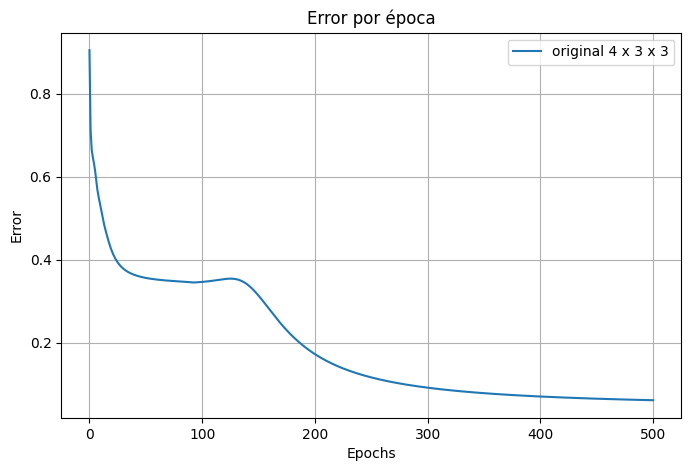

In [8]:
from sklearn.metrics import f1_score

def predict_original_numpy(sample):
  output_layer1 = np.zeros(num_neurons_layer1)
  for i in range(len(output_layer1)):
    output_layer1[i] = propagate(sample, layer1[i])

  output_layer2 = np.zeros(num_neurons_layer2)
  for i in range(len(output_layer2)):
    output_layer2[i] = propagate(output_layer1, layer2[i])

  return output_layer2

def accuracy_original_numpy():
  correct = 0
  for idx in range(len(X)):
    prediction = np.argmax(predict_original_numpy(X[idx]))
    if prediction == target[idx]:
      correct += 1
  return correct / len(X)

# Calculate F1 score for the original network
def f1_score_original_numpy():
  y_true = np.argmax(Y, axis=1) # Convert one-hot to single labels
  y_pred = np.array([np.argmax(predict_original_numpy(sample)) for sample in X])
  return f1_score(y_true, y_pred, average='weighted')

print("sampled errors")
for epoch in range(0, len(E), 50):
  print(f"epoch {epoch:03d} error={E[epoch]:.6f}")
if (len(E) - 1) % 50 != 0:
  print(f"epoch {len(E) - 1:03d} error={E[-1]:.6f}")

print(f"final error={E[-1]:.6f}")
print(f"accuracy={accuracy_original_numpy():.4f}")
print(f"f1_score={f1_score_original_numpy():.4f}")
print("prediction [3, 3, 1, 1] =", predict_original_numpy(np.array([3, 3, 1, 1])))

plt.figure(figsize=(8, 5))
plt.plot(np.asarray(E), label="original 4 x 3 x 3")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Error por época")
plt.legend()
plt.grid(True)
plt.show()

## Red profunda NumPy: topologia 4 x 3 x 3 x 3 x 3

Estas celdas nuevas agregan exactamente dos capas ocultas a la red original.
Se mantiene sigmoide en todas las capas, MSE, SGD, `alpha = 0.03` y 500 epocas.

In [9]:
# Topology: 4 x 3 x 3 x 3 x 3
input_size_layer1_deep = 4
num_neurons_layer1_deep = 3

input_size_layer2_deep = num_neurons_layer1_deep
num_neurons_layer2_deep = 3

input_size_layer3_deep = num_neurons_layer2_deep
num_neurons_layer3_deep = 3

input_size_layer4_deep = num_neurons_layer3_deep
num_neurons_layer4_deep = 3

layer1_deep = list()
layer2_deep = list()
layer3_deep = list()
layer4_deep = list()
deep_layers = [layer1_deep, layer2_deep, layer3_deep, layer4_deep]

def generate_weights_deep(num_weights):
  w = np.zeros(num_weights)
  for i in range(len(w)):
    w[i] = np.random.rand() - 0.5
  return w

def init_weights_deep():
  for layer in deep_layers:
    layer.clear()

  for i in range(num_neurons_layer1_deep):
    layer1_deep.append(generate_weights_deep(input_size_layer1_deep + 1))
  for i in range(num_neurons_layer2_deep):
    layer2_deep.append(generate_weights_deep(input_size_layer2_deep + 1))
  for i in range(num_neurons_layer3_deep):
    layer3_deep.append(generate_weights_deep(input_size_layer3_deep + 1))
  for i in range(num_neurons_layer4_deep):
    layer4_deep.append(generate_weights_deep(input_size_layer4_deep + 1))

def forward_deep_numpy(sample):
  outputs = []
  current_input = sample
  for layer in deep_layers:
    output = np.zeros(len(layer))
    for i in range(len(layer)):
      output[i] = propagate(current_input, layer[i])
    outputs.append(output)
    current_input = output
  return outputs

def calculate_error_deep_numpy():
  total_err = 0
  for idx in range(len(X)):
    output_layer4 = forward_deep_numpy(X[idx])[-1]
    err = Y[idx] - output_layer4
    err = np.power(err, 2)
    err = err.sum()
    total_err += err
  return total_err / len(X)

def predict_deep_numpy(sample):
  return forward_deep_numpy(sample)[-1]

def accuracy_deep_numpy():
  correct = 0
  for idx in range(len(X)):
    prediction = np.argmax(predict_deep_numpy(X[idx]))
    if prediction == target[idx]:
      correct += 1
  return correct / len(X)

epoch 000 error=0.756430
epoch 050 error=0.670793
epoch 100 error=0.670221
epoch 150 error=0.668028
epoch 200 error=0.633891
epoch 250 error=0.354453
epoch 300 error=0.353425
epoch 350 error=0.311279
epoch 400 error=0.204415
epoch 450 error=0.128718
epoch 500 error=0.102275
final error=0.102275
accuracy=0.9467
f1_score=0.9463
training_time_seconds=14.8926
prediction [3, 3, 1, 1] = [9.44205641e-01 1.14426184e-01 2.83967772e-04]


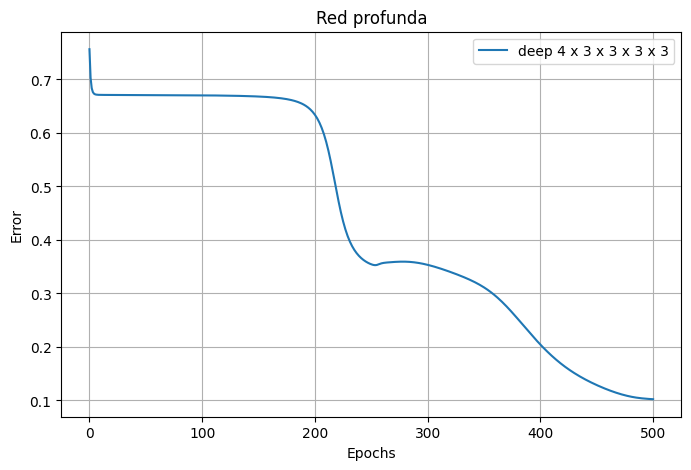

In [10]:
import time
from sklearn.metrics import f1_score

alpha_deep = 0.03
epochs_deep = 500

np.random.seed(7)
init_weights_deep()

E_deep = list()
E_deep.append(calculate_error_deep_numpy())
print(f"epoch 000 error={E_deep[-1]:.6f}")

start_time = time.perf_counter()
for e in range(epochs_deep):
  for d in range(len(X)):
    # Etapa 1 - Propagacion hacia adelante
    outputs = forward_deep_numpy(X[d])

    # Etapa 2 - Retropropagacion desde salida hacia entrada
    deltas = [None] * len(deep_layers)
    output_layer4 = outputs[-1]
    delta_layer4 = np.zeros(num_neurons_layer4_deep)
    for i in range(len(delta_layer4)):
      delta_layer4[i] = output_layer4[i] * (1 - output_layer4[i]) * (Y[d][i] - output_layer4[i])
    deltas[-1] = delta_layer4

    for layer_idx in range(len(deep_layers) - 2, -1, -1):
      current_output = outputs[layer_idx]
      next_layer = deep_layers[layer_idx + 1]
      next_delta = deltas[layer_idx + 1]

      current_delta = np.zeros(len(current_output))
      for i in range(len(current_output)):
        weighted_delta_errors = 0
        for j in range(len(next_layer)):
          weighted_delta_errors += next_layer[j][i + 1] * next_delta[j]
        current_delta[i] = current_output[i] * (1 - current_output[i]) * weighted_delta_errors
      deltas[layer_idx] = current_delta

    inputs_by_layer = [X[d], outputs[0], outputs[1], outputs[2]]
    for layer_idx, layer in enumerate(deep_layers):
      layer_input = inputs_by_layer[layer_idx]
      layer_delta = deltas[layer_idx]
      for i in range(len(layer)):
        layer[i][0] += alpha_deep * layer_delta[i] * 1
        for j in range(len(layer[i]) - 1):
          layer[i][j + 1] += alpha_deep * layer_delta[i] * layer_input[j]

  E_deep.append(calculate_error_deep_numpy())
  if (e + 1) % 50 == 0:
    print(f"epoch {e + 1:03d} error={E_deep[-1]:.6f}")

training_time_deep_numpy = time.perf_counter() - start_time

# Calculate F1 score for the deep network
def f1_score_deep_numpy():
  y_true = np.argmax(Y, axis=1) # Convert one-hot to single labels
  y_pred = np.array([np.argmax(predict_deep_numpy(sample)) for sample in X])
  return f1_score(y_true, y_pred, average='weighted')

print(f"final error={E_deep[-1]:.6f}")
print(f"accuracy={accuracy_deep_numpy():.4f}")
print(f"f1_score={f1_score_deep_numpy():.4f}")
print(f"training_time_seconds={training_time_deep_numpy:.4f}")
print("prediction [3, 3, 1, 1] =", predict_deep_numpy(np.array([3, 3, 1, 1])))

plt.figure(figsize=(8, 5))
plt.plot(np.asarray(E_deep), label="deep 4 x 3 x 3 x 3 x 3")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Red profunda")
plt.legend()
plt.grid(True)
plt.show()

## Análisis de estabilidad del error con 30 corridas

Esta seccion entrena desde cero 30 veces la red original `4 x 3 x 3` y la red
profunda `4 x 3 x 3 x 3 x 3`. Se mantienen sigmoide, MSE, SGD, `alpha = 0.03`
y 500 epocas. Cada corrida usa una semilla distinta para observar que tan
estable es el error final.

In [11]:
import time

STABILITY_RUNS = 30
STABILITY_EPOCHS = 500
STABILITY_ALPHA = 0.03
STABILITY_BASE_SEED = 2026

def stability_sigmoid(z):
  return 1 / (1 + np.exp(-z))

def init_numpy_mlp(layer_sizes, seed):
  rng = np.random.default_rng(seed)
  weights = []
  for input_size, output_size in zip(layer_sizes[:-1], layer_sizes[1:]):
    weights.append(rng.uniform(-0.5, 0.5, size=(input_size + 1, output_size)))
  return weights

def forward_numpy_mlp(sample, weights):
  activations = [sample.astype(float)]
  for W in weights:
    activation_with_bias = np.insert(activations[-1], 0, 1.0)
    activations.append(stability_sigmoid(activation_with_bias @ W))
  return activations

def mse_numpy_mlp(weights):
  total_error = 0.0
  for sample, expected in zip(X, Y):
    output = forward_numpy_mlp(sample, weights)[-1]
    total_error += np.sum((expected - output) ** 2)
  return total_error / len(X)

def accuracy_numpy_mlp(weights):
  predictions = []
  for sample in X:
    output = forward_numpy_mlp(sample, weights)[-1]
    predictions.append(np.argmax(output))
  return np.mean(np.asarray(predictions) == target)

def train_numpy_mlp_once(layer_sizes, seed):
  weights = init_numpy_mlp(layer_sizes, seed)
  errors = [mse_numpy_mlp(weights)]

  for epoch in range(STABILITY_EPOCHS):
    for sample, expected in zip(X, Y):
      activations = forward_numpy_mlp(sample, weights)

      deltas = [None] * len(weights)
      output = activations[-1]
      deltas[-1] = output * (1 - output) * (expected - output)

      for layer_idx in range(len(weights) - 2, -1, -1):
        current_output = activations[layer_idx + 1]
        next_weights = weights[layer_idx + 1]
        next_delta = deltas[layer_idx + 1]
        weighted_error = next_weights[1:, :] @ next_delta
        deltas[layer_idx] = current_output * (1 - current_output) * weighted_error

      for layer_idx, W in enumerate(weights):
        layer_input = np.insert(activations[layer_idx], 0, 1.0)
        W += STABILITY_ALPHA * np.outer(layer_input, deltas[layer_idx])

    errors.append(mse_numpy_mlp(weights))

  return {
    "seed": seed,
    "final_error": errors[-1],
    "accuracy": accuracy_numpy_mlp(weights),
    "errors": errors,
  }

def summarize_numpy_stability(label, results):
  final_errors = np.asarray([r["final_error"] for r in results])
  accuracies = np.asarray([r["accuracy"] for r in results])
  print(f"\nResumen {label}")
  print(f"runs={len(results)} epochs={STABILITY_EPOCHS} alpha={STABILITY_ALPHA}")
  print(f"final_error_mean={final_errors.mean():.6f}")
  print(f"final_error_std={final_errors.std(ddof=1):.6f}")
  print(f"final_error_min={final_errors.min():.6f}")
  print(f"final_error_max={final_errors.max():.6f}")
  print(f"accuracy_mean={accuracies.mean():.4f}")
  print(f"accuracy_std={accuracies.std(ddof=1):.4f}")
  print(f"accuracy_min={accuracies.min():.4f}")
  print(f"accuracy_max={accuracies.max():.4f}")

def run_numpy_stability():
  original_results = []
  deep_results = []
  start_time = time.perf_counter()

  for run_idx in range(STABILITY_RUNS):
    seed = STABILITY_BASE_SEED + run_idx
    original = train_numpy_mlp_once([4, 3, 3], seed)
    deep = train_numpy_mlp_once([4, 3, 3, 3, 3], seed)
    original_results.append(original)
    deep_results.append(deep)
    print(
      f"run {run_idx + 1:02d}/{STABILITY_RUNS} seed={seed} "
      f"original_error={original['final_error']:.6f} original_acc={original['accuracy']:.4f} "
      f"deep_error={deep['final_error']:.6f} deep_acc={deep['accuracy']:.4f}"
    )

  elapsed = time.perf_counter() - start_time
  summarize_numpy_stability("NumPy original 4 x 3 x 3", original_results)
  summarize_numpy_stability("NumPy deep 4 x 3 x 3 x 3 x 3", deep_results)
  print(f"\nNumPy stability total_time_seconds={elapsed:.4f}")

  return original_results, deep_results

numpy_original_30, numpy_deep_30 = run_numpy_stability()

run 01/30 seed=2026 original_error=0.060861 original_acc=0.9667 deep_error=0.250101 deep_acc=0.8333
run 02/30 seed=2027 original_error=0.089609 original_acc=0.9467 deep_error=0.114253 deep_acc=0.9333
run 03/30 seed=2028 original_error=0.060812 original_acc=0.9667 deep_error=0.113961 deep_acc=0.9467
run 04/30 seed=2029 original_error=0.058718 original_acc=0.9667 deep_error=0.351002 deep_acc=0.6733
run 05/30 seed=2030 original_error=0.059488 original_acc=0.9667 deep_error=0.400732 deep_acc=0.6733
run 06/30 seed=2031 original_error=0.058359 original_acc=0.9667 deep_error=0.378675 deep_acc=0.6733
run 07/30 seed=2032 original_error=0.060524 original_acc=0.9667 deep_error=0.260207 deep_acc=0.8333
run 08/30 seed=2033 original_error=0.057565 original_acc=0.9667 deep_error=0.305647 deep_acc=0.8133
run 09/30 seed=2034 original_error=0.056694 original_acc=0.9667 deep_error=0.671364 deep_acc=0.3333
run 10/30 seed=2035 original_error=0.058436 original_acc=0.9667 deep_error=0.275280 deep_acc=0.8133


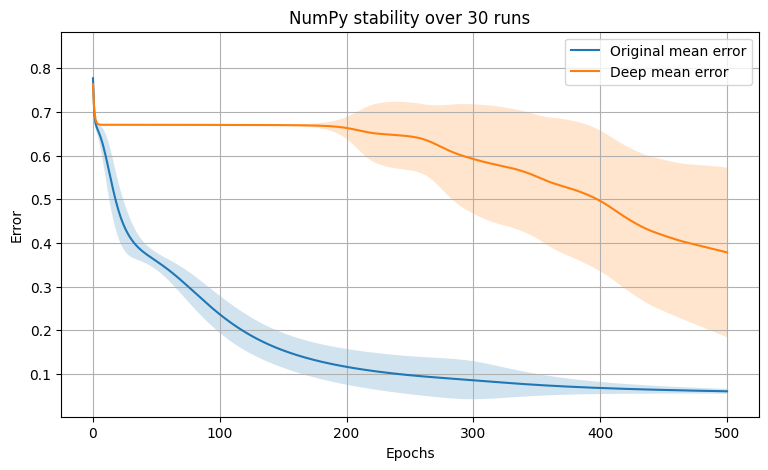

/tmp/ipykernel_580/3650743319.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


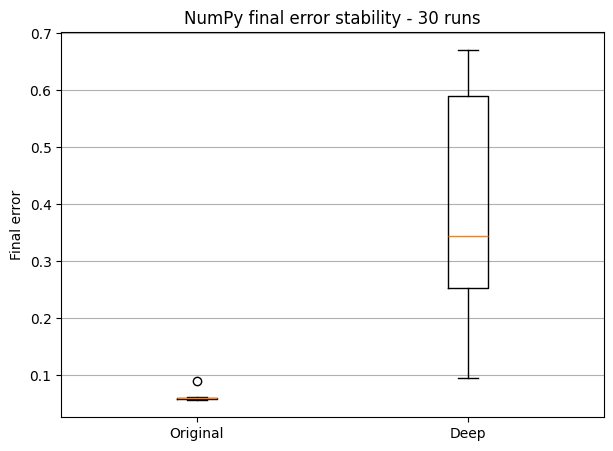

NumPy final error comparison
original_errors = [np.float64(0.060861), np.float64(0.089609), np.float64(0.060812), np.float64(0.058718), np.float64(0.059488), np.float64(0.058359), np.float64(0.060524), np.float64(0.057565), np.float64(0.056694), np.float64(0.058436), np.float64(0.059776), np.float64(0.059538), np.float64(0.056901), np.float64(0.058501), np.float64(0.058415), np.float64(0.059225), np.float64(0.060719), np.float64(0.058512), np.float64(0.05782), np.float64(0.060146), np.float64(0.059343), np.float64(0.059193), np.float64(0.059895), np.float64(0.058145), np.float64(0.061823), np.float64(0.058646), np.float64(0.059389), np.float64(0.057822), np.float64(0.058519), np.float64(0.059128)]
deep_errors     = [np.float64(0.250101), np.float64(0.114253), np.float64(0.113961), np.float64(0.351002), np.float64(0.400732), np.float64(0.378675), np.float64(0.260207), np.float64(0.305647), np.float64(0.671364), np.float64(0.27528), np.float64(0.669933), np.float64(0.67071), np.float64(0

In [12]:
def curves_matrix(results):
  return np.asarray([r["errors"] for r in results])

original_curves = curves_matrix(numpy_original_30)
deep_curves = curves_matrix(numpy_deep_30)

plt.figure(figsize=(9, 5))
plt.plot(original_curves.mean(axis=0), label="Original mean error")
plt.fill_between(
  np.arange(original_curves.shape[1]),
  original_curves.mean(axis=0) - original_curves.std(axis=0),
  original_curves.mean(axis=0) + original_curves.std(axis=0),
  alpha=0.20,
)
plt.plot(deep_curves.mean(axis=0), label="Deep mean error")
plt.fill_between(
  np.arange(deep_curves.shape[1]),
  deep_curves.mean(axis=0) - deep_curves.std(axis=0),
  deep_curves.mean(axis=0) + deep_curves.std(axis=0),
  alpha=0.20,
)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("NumPy stability over 30 runs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.boxplot(
  [
    [r["final_error"] for r in numpy_original_30],
    [r["final_error"] for r in numpy_deep_30],
  ],
  labels=["Original", "Deep"],
)
plt.ylabel("Final error")
plt.title("NumPy final error stability - 30 runs")
plt.grid(True, axis="y")
plt.show()

print("NumPy final error comparison")
print("original_errors =", [round(r["final_error"], 6) for r in numpy_original_30])
print("deep_errors     =", [round(r["final_error"], 6) for r in numpy_deep_30])